# Pelatihan DNABERT-2 — Klasifikasi Patogenisitas Varian DNA (ClinVar)

Notebook ini melatih DNABERT-2 untuk klasifikasi biner: **Benign (0)** vs **Pathogenic (1)**.

**Dataset:** `InstaDeepAI/genomics-long-range-benchmark`
**Task:** `variant_effect_pathogenic_clinvar`
**Kolom input:** `ref_forward_sequence` (referensi) & `alt_forward_sequence` (dengan mutasi)
**Label:** 0 = benign/non-patogenik, 1 = patogenik

> **Metodologi (Feng et al., Nature Comms 2025):**
> Representasi input: `concat[alt_emb || ref_emb || (alt_emb − ref_emb)]` (dimensi 2304).
> Pure difference embedding saja tidak cukup untuk SNV karena sekuens 512bp yang hanya
> berbeda 1 nukleotida menghasilkan diff ≈ 0, menyebabkan model collapse ke majority class.
> Concat mempertahankan konteks individual tiap sekuens sekaligus menangkap efek mutasi.
> Mean pooling atas semua token non-padding secara konsisten lebih baik dari [CLS].

**Alur kerja:**
1. Pengecekan GPU dan instalasi
2. Konfigurasi terpusat
3. Pemuatan tokenizer + patch kompatibilitas
4. Pemuatan dataset InstaDeepAI ClinVar
5. EDA dan verifikasi nama kolom
6. Dataset class + tokenisasi DNABERT-2
7. Arsitektur model (concat embedding)
8. Training loop (freeze → unfreeze)
9. Evaluasi dan visualisasi
10. Penyimpanan model
11. Demo inferensi

**Catatan Kaggle:** Aktifkan GPU T4/P100 di Settings > Accelerator.

## 1. Pengecekan GPU dan Instalasi Paket

In [1]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA tersedia   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("PERINGATAN: GPU tidak terdeteksi. Training sangat lambat di CPU.")

PyTorch version : 2.10.0+cu128
CUDA tersedia   : True
GPU             : Tesla T4
VRAM            : 15.6 GB


In [ ]:
# transformers 4.35.2 kompatibel dengan DNABERT-2 custom code di Kaggle T4
# datasets<3.0.0 menghindari breaking API change pada load_dataset
install("transformers==4.35.2")
install("einops")
install("datasets<3.0.0")
install("pyfaidx")
# install("scikit-learn")
# install("tqdm")
# install("matplotlib")
# install("seaborn")
print("Instalasi selesai.")

## 2. Import Library dan Konfigurasi

`SEQ_LENGTH` menentukan panjang sekuens konteks DNA (nukleotida) yang diambil
di sekitar posisi varian. Nilai 512bp cukup untuk menangkap konteks lokal
sekitar mutasi dan kompatibel dengan batas token DNABERT-2.

In [2]:
import os, random, warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer, AutoModel, AutoConfig,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
)
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import json

warnings.filterwarnings("ignore")

# ── Konfigurasi utama ──────────────────────────────────────────────────────
SEED          = 42
TRAIN_SIZE    = 20_000   # InstaDeepAI ClinVar punya ~38k train
TEST_SIZE     = 1_000    # ~1.018 tersedia
SEQ_LENGTH    = 512      # panjang sekuens konteks DNA (nukleotida)
MAX_TOK_LEN   = 512      # batas token DNABERT-2
BATCH_SIZE    = 16
EPOCHS        = 6
LR            = 2e-5
FREEZE_EPOCHS = 1        # 1 epoch freeze head-only sudah cukup untuk warmup
HIDDEN_DIM    = 512      # lebih besar karena input 2304-dim (3× encoder_dim)
DROPOUT       = 0.1
NUM_CLASSES   = 2        # Benign=0, Pathogenic=1
MODEL_NAME    = "zhihan1996/DNABERT-2-117M"
LABEL_NAMES   = ["Benign", "Pathogenic"]

# Class weights manual — lebih agresif untuk Benign agar tidak collapse
# Dataset hampir seimbang (44/56), tapi diff embedding hampir nol untuk SNV
# sehingga model butuh push lebih kuat agar tidak ignore Benign
MANUAL_CLASS_WEIGHTS = [2.5, 1.0]  # [Benign, Pathogenic]

IS_KAGGLE      = os.path.exists("/kaggle")
MODEL_SAVE_DIR = "/kaggle/working/models" if IS_KAGGLE else "./models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Model      : {MODEL_NAME}")
print(f"Classes    : {NUM_CLASSES} — {LABEL_NAMES}")
print(f"Seq length : {SEQ_LENGTH} bp")
print(f"Train size : {TRAIN_SIZE:,}  |  Test size : {TEST_SIZE:,}")
print(f"Output dir : {MODEL_SAVE_DIR}")
print(f"Device     : {DEVICE}")
print(f"Freeze     : {FREEZE_EPOCHS} epoch(s)")
print(f"Class wts  : Benign={MANUAL_CLASS_WEIGHTS[0]}, Pathogenic={MANUAL_CLASS_WEIGHTS[1]}")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Model      : zhihan1996/DNABERT-2-117M
Classes    : 2 — ['Benign', 'Pathogenic']
Seq length : 512 bp
Train size : 20,000  |  Test size : 1,000
Output dir : /kaggle/working/models
Device     : cuda
Freeze     : 1 epoch(s)
Class wts  : Benign=2.5, Pathogenic=1.0


## 3. Pemuatan Tokenizer dan Patch Kompatibilitas

DNABERT-2 menggunakan custom code yang di-cache oleh HuggingFace. Beberapa patch
diperlukan untuk kompatibilitas dengan Triton 3.x di Kaggle GPU environment:
- **Triton syntax patch**: `tl.dot(..., trans_b=True)` → `tl.dot(..., tl.trans(...))`
- **PyTorch native SDPA**: mengganti custom flash_attn kernel dengan `F.scaled_dot_product_attention`
  yang otomatis menyesuaikan dengan batas Shared Memory GPU T4 (64KB)
- **AutoModel monkey patch**: mengatasi konflik `config_class` pada registrasi model custom

Patch diterapkan ke file cache setelah tokenizer diunduh.

In [3]:
# Load tokenizer dulu agar HuggingFace mengunduh semua custom code ke cache
print("Mengunduh tokenizer DNABERT-2 (memicu download custom code)...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
print(f"Vocabulary size: {tokenizer.vocab_size}")

Mengunduh tokenizer DNABERT-2 (memicu download custom code)...
Vocabulary size: 4096


In [ ]:
import glob, re

# ── Patch 1: Triton syntax compatibility ──────────────────────────────────
cache_pattern = os.path.expanduser(
    "~/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT-2-117M/*/flash_attn_triton.py"
)
files = glob.glob(cache_pattern)

patch_sdpa = '''

# =====================================================================
# PATCH NATIVE PYTORCH (Solusi OutOfMemory/Triton pada Kaggle T4)
# Mengganti custom triton kernel dengan fungsi bawaan PyTorch yang
# menyesuaikan otomatis dengan batas Shared Memory GPU T4 (64KB).
# =====================================================================
import torch
import torch.nn.functional as F

def flash_attn_qkvpacked_func(qkv, bias=None, causal=False, softmax_scale=None):
    # qkv: [batch_size, seq_len, 3, num_heads, head_dim]
    q = qkv[:, :, 0].transpose(1, 2)
    k = qkv[:, :, 1].transpose(1, 2)
    v = qkv[:, :, 2].transpose(1, 2)
    if bias is not None and bias.dtype != q.dtype:
        bias = bias.to(q.dtype)
    out = F.scaled_dot_product_attention(q, k, v, attn_mask=bias, is_causal=causal)
    return out.transpose(1, 2).contiguous()
'''

if not files:
    print("File flash_attn_triton.py tidak ditemukan di cache — mungkin sudah dipatch atau belum diunduh.")
else:
    for fpath in files:
        with open(fpath, "r") as f:
            content = f.read()

        # Patch 1a: Triton 2.x → 3.x syntax
        content = re.sub(
            r"tl\.dot\((.*?),\s*(.*?),\s*trans_b=True\)",
            r"tl.dot(\1, tl.trans(\2))",
            content,
        )
        content = re.sub(
            r"tl\.dot\((.*?),\s*(.*?),\s*trans_a=True\)",
            r"tl.dot(tl.trans(\1), \2)",
            content,
        )

        # Patch 1b: PyTorch native SDPA (hanya tambahkan jika belum ada)
        if "PATCH NATIVE PYTORCH" not in content:
            content += patch_sdpa

        with open(fpath, "w") as f:
            f.write(content)

    print(f"Berhasil menambal {len(files)} file untuk kompatibilitas Triton 3.x + SDPA.")

In [ ]:
# ── Patch 2: AutoModel monkey patch ───────────────────────────────────────
# Mengatasi konflik config_class pada registrasi model DNABERT-2 custom.
# Guard _patched flag agar idempotent — aman dijalankan ulang.
from transformers.models.auto.auto_factory import _BaseAutoModelClass

if not getattr(_BaseAutoModelClass.register, "_patched", False):
    _original_register = _BaseAutoModelClass.register

    @classmethod
    def _patched_register(cls, config_class, model_class, exist_ok=False):
        if hasattr(model_class, "config_class") and model_class.config_class != config_class:
            model_class.config_class = config_class
        return _original_register.__func__(cls, config_class, model_class, exist_ok=exist_ok)

    _patched_register._patched = True
    _BaseAutoModelClass.register = _patched_register
    print("AutoModel monkey patch terpasang.")
else:
    print("AutoModel monkey patch sudah terpasang, skip.")

## 4. Pemuatan Dataset ClinVar (InstaDeepAI)

Kolom yang digunakan dari dataset ini:
- `ref_forward_sequence` — sekuens referensi (tanpa mutasi)
- `alt_forward_sequence` — sekuens dengan mutasi (yang diprediksi)
- `label` — 0 = benign, 1 = pathogenic

In [4]:
print("Memuat dataset InstaDeepAI ClinVar pathogenicity...")

raw_dataset = load_dataset(
    "InstaDeepAI/genomics-long-range-benchmark",
    task_name="variant_effect_pathogenic_clinvar",
    sequence_length=SEQ_LENGTH,
    trust_remote_code=True,
)

print("\nSplit yang tersedia:")
for split, ds in raw_dataset.items():
    print(f"  {split:6s}: {len(ds):,} sampel  |  kolom: {list(ds.features.keys())}")

Memuat dataset InstaDeepAI ClinVar pathogenicity...

Split yang tersedia:
  train : 38,634 sampel  |  kolom: ['ref_forward_sequence', 'alt_forward_sequence', 'label', 'chromosome', 'position']
  test  : 1,018 sampel  |  kolom: ['ref_forward_sequence', 'alt_forward_sequence', 'label', 'chromosome', 'position']


In [5]:
train_raw = raw_dataset["train"].shuffle(seed=SEED).select(
    range(min(TRAIN_SIZE, len(raw_dataset["train"])))
)
test_raw = raw_dataset["test"].shuffle(seed=SEED).select(
    range(min(TEST_SIZE, len(raw_dataset["test"])))
)

print(f"Train subset : {len(train_raw):,} sampel")
print(f"Test subset  : {len(test_raw):,} sampel")
print()
print("Contoh data (satu baris):")
sample = dict(train_raw[0])
for k, v in sample.items():
    display_v = f"{str(v)[:80]}..." if isinstance(v, str) and len(str(v)) > 80 else v
    print(f"  {k}: {display_v}")

Train subset : 20,000 sampel
Test subset  : 1,000 sampel

Contoh data (satu baris):
  ref_forward_sequence: AACCTCGATTTTCTTCCGCCATCCGGCTAAATAGTCCCATGTGCACTTTGTTCCATGGATAAATAAACACTAGGAACGCA...
  alt_forward_sequence: AACCTCGATTTTCTTCCGCCATCCGGCTAAATAGTCCCATGTGCACTTTGTTCCATGGATAAATAAACACTAGGAACGCA...
  label: 1
  chromosome: 12
  position: 56042168


## 5. Eksplorasi Data (EDA)

Verifikasi nama kolom dan distribusi kelas sebelum training.
Dataset InstaDeepAI menggunakan nama kolom `ref_forward_sequence` dan
`alt_forward_sequence` — bukan `ref`/`alt`.

In [6]:
import pandas as pd

df_train = pd.DataFrame(train_raw)
print(f"Kolom dataset: {df_train.columns.tolist()}")

assert "alt_forward_sequence" in df_train.columns, "KOLOM alt_forward_sequence TIDAK DITEMUKAN!"
assert "ref_forward_sequence" in df_train.columns, "KOLOM ref_forward_sequence TIDAK DITEMUKAN!"
assert "label" in df_train.columns, "KOLOM label TIDAK DITEMUKAN!"
print("Semua kolom kritis tersedia.")
print()

dist = df_train["label"].value_counts().sort_index()
print("Distribusi kelas (train subset):")
for cls_idx, cnt in dist.items():
    cls_name = LABEL_NAMES[int(cls_idx)]
    pct = cnt / len(df_train) * 100
    bar = "#" * int(pct / 2)
    print(f"  {cls_idx} ({cls_name:<12}): {cnt:6,}  ({pct:5.1f}%)  {bar}")

Kolom dataset: ['ref_forward_sequence', 'alt_forward_sequence', 'label', 'chromosome', 'position']
Semua kolom kritis tersedia.

Distribusi kelas (train subset):
  0 (Benign      ):  8,794  ( 44.0%)  #####################
  1 (Pathogenic  ): 11,206  ( 56.0%)  ############################


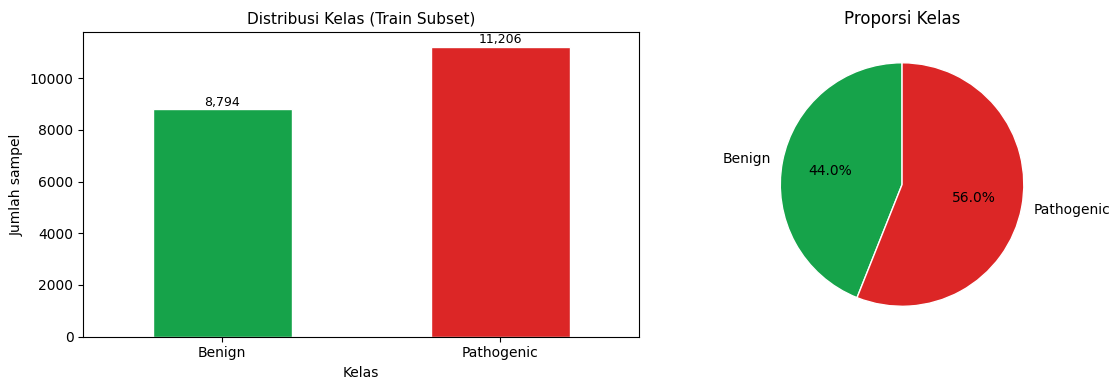

Panjang alt_forward_sequence: min=512, max=512, mean=512
Panjang ref_forward_sequence: min=512, max=512, mean=512
Sekuens kosong (alt): 0 — harus 0
Sekuens kosong (ref): 0 — harus 0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dist = df_train["label"].value_counts().sort_index()
labels_display = [LABEL_NAMES[int(i)] for i in dist.index]
colors = ["#16a34a", "#dc2626"]

dist.plot(kind="bar", ax=axes[0], color=colors, edgecolor="white")
axes[0].set_xticklabels(labels_display, rotation=0)
axes[0].set_title("Distribusi Kelas (Train Subset)", fontsize=11)
axes[0].set_xlabel("Kelas"); axes[0].set_ylabel("Jumlah sampel")
for patch in axes[0].patches:
    axes[0].text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 20,
        f"{int(patch.get_height()):,}",
        ha="center", va="bottom", fontsize=9,
    )

dist.plot(kind="pie", ax=axes[1], labels=labels_display, colors=colors,
          autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proporsi Kelas"); axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

alt_lens = df_train["alt_forward_sequence"].str.len()
ref_lens = df_train["ref_forward_sequence"].str.len()
print(f"Panjang alt_forward_sequence: min={alt_lens.min()}, max={alt_lens.max()}, mean={alt_lens.mean():.0f}")
print(f"Panjang ref_forward_sequence: min={ref_lens.min()}, max={ref_lens.max()}, mean={ref_lens.mean():.0f}")
print(f"Sekuens kosong (alt): {(alt_lens == 0).sum()} — harus 0")
print(f"Sekuens kosong (ref): {(ref_lens == 0).sum()} — harus 0")

## 6. Dataset Class dan Tokenisasi DNABERT-2

Dataset mengembalikan **dua pasang token**: ref dan alt — keduanya diperlukan
untuk menghitung representasi concat `[alt_emb || ref_emb || (alt_emb - ref_emb)]`.

DNABERT-2 menggunakan BPE tokenizer dengan 4.096 token. Dengan sekuens 512bp,
biasanya hanya 150-300 token aktif (sisanya padding), sehingga mean pooling
hanya dihitung atas token non-padding.

In [8]:
class DNAVariantDataset(Dataset):
    """
    Mengembalikan pasangan (ref, alt) tokenized + label.
    Kolom: ref_forward_sequence, alt_forward_sequence, label
    """

    def __init__(self, data, tokenizer, max_length: int = MAX_TOK_LEN):
        self.data       = data
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        ref_seq = str(item.get("ref_forward_sequence") or item.get("ref") or "").upper()
        alt_seq = str(item.get("alt_forward_sequence") or item.get("alt") or "").upper()
        label   = int(item.get("label", 0))

        def tok(seq):
            return self.tokenizer(
                seq,
                max_length=self.max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )

        ref_enc = tok(ref_seq)
        alt_enc = tok(alt_seq)

        return {
            "ref_input_ids":      ref_enc["input_ids"].squeeze(0),
            "ref_attention_mask": ref_enc["attention_mask"].squeeze(0),
            "alt_input_ids":      alt_enc["input_ids"].squeeze(0),
            "alt_attention_mask": alt_enc["attention_mask"].squeeze(0),
            "label":              torch.tensor(label, dtype=torch.long),
        }


train_dataset = DNAVariantDataset(train_raw, tokenizer)
test_dataset  = DNAVariantDataset(test_raw,  tokenizer)

sample = train_dataset[0]
print("Contoh item dataset:")
for k, v in sample.items():
    if isinstance(v, torch.Tensor):
        active = v.sum().item() if "mask" in k else "—"
        print(f"  {k:<25}: shape {v.shape}  active_tokens={active}")
    else:
        print(f"  {k}: {v.item()}")

assert sample["ref_attention_mask"].sum() > 0, "REF sequences kosong — periksa nama kolom!"
assert sample["alt_attention_mask"].sum() > 0, "ALT sequences kosong — periksa nama kolom!"
print("\nVerifikasi: semua sekuens tidak kosong.")

Contoh item dataset:
  ref_input_ids            : shape torch.Size([512])  active_tokens=—
  ref_attention_mask       : shape torch.Size([512])  active_tokens=108
  alt_input_ids            : shape torch.Size([512])  active_tokens=—
  alt_attention_mask       : shape torch.Size([512])  active_tokens=108
  label                    : shape torch.Size([])  active_tokens=—

Verifikasi: semua sekuens tidak kosong.


In [9]:
num_workers = 2 if IS_KAGGLE else 0

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=num_workers, pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=torch.cuda.is_available(),
)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 1250
Test batches  : 63


## 7. Arsitektur Model: DNABERT-2 + Concat Embedding

**Mengapa concat, bukan pure difference?**

Untuk SNV (Single Nucleotide Variant) dengan sekuens 512bp, perbedaan hanya
1 nukleotida menghasilkan `alt_emb - ref_emb ≈ 0`. Model yang hanya menerima
sinyal mendekati nol akan collapse ke prediksi majority class (Pathogenic).

Representasi concat `[alt_emb || ref_emb || diff_emb]` memberikan tiga sinyal:
- `alt_emb`: konteks sekuens dengan mutasi
- `ref_emb`: konteks sekuens referensi
- `diff_emb`: efek mutasi (sinyal kecil tapi tetap dipertahankan)

```
ref_forward_sequence → DNABERT-2 → mean_pool → ref_emb  [768]
alt_forward_sequence → DNABERT-2 → mean_pool → alt_emb  [768]
                                                    ↓
                            concat[alt_emb || ref_emb || (alt_emb-ref_emb)] [2304]
                                                    ↓
                                    Linear(2304→512) → ReLU → Dropout
                                                    ↓
                                           Linear(512→2) → logits
```

**Strategi training dua fase:**
- Fase 1 (1 epoch): Encoder dibekukan → warmup head saja
- Fase 2 (epoch berikutnya): Full fine-tuning seluruh model

In [10]:
import torch
import torch.nn as nn
from transformers import AutoModel

# ====================================================================
# BYPASS BUG HUGGINGFACE (MONKEY PATCH)
# Mematikan pengecekan config_class yang bentrok pada DNABERT-2
# ====================================================================
from transformers.models.auto.auto_factory import _BaseAutoModelClass

_original_register = _BaseAutoModelClass.register

@classmethod
def _patched_register(cls, config_class, model_class, exist_ok=False):
    # Jika terdeteksi ada bentrok pada config_class, kita paksa samakan
    if hasattr(model_class, "config_class") and model_class.config_class != config_class:
        model_class.config_class = config_class
    
    # Lanjutkan proses registrasi model secara normal
    return _original_register.__func__(cls, config_class, model_class, exist_ok=exist_ok)

# Terapkan patch ke library transformers
_BaseAutoModelClass.register = _patched_register
# ====================================================================


# Definisikan model Anda dengan logika perbandingan Alt dan Ref
class DNAVariantClassifier(nn.Module):
    def __init__(self, model_name=MODEL_NAME, num_classes=NUM_CLASSES,
                 hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        
        # Pemuatan model menggunakan cara aman (tanpa argumen config terpisah)
        self.encoder = AutoModel.from_pretrained(
            model_name, trust_remote_code=True
        )
        
        encoder_dim = getattr(self.encoder.config, "hidden_size", 768)
        
        self.classifier = nn.Sequential(
            nn.Linear(encoder_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def _mean_pool(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out[0]                                # [B, seq_len, H]
        mask   = attention_mask.unsqueeze(-1).float()  # [B, seq_len, 1]
        return (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

    def forward(self, alt_input_ids, alt_attention_mask,
                ref_input_ids, ref_attention_mask):
        
        # Dapatkan representasi sekuens untuk masing-masing varian
        alt_emb  = self._mean_pool(alt_input_ids, alt_attention_mask)
        ref_emb  = self._mean_pool(ref_input_ids, ref_attention_mask)
        
        # Hitung selisih (efek mutasi)
        diff_emb = alt_emb - ref_emb   
        
        # Masukkan ke klasifikator
        return self.classifier(diff_emb)

    def freeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = False

    def unfreeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = True

    def count_params(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable


# Test pemuatan model
print("Memuat DNABERT-2 (117M parameter)...")
model = DNAVariantClassifier().to(DEVICE)
total, trainable = model.count_params()

print(f"Total parameter   : {total:,}")
print(f"Trainable (awal)  : {trainable:,}  (berubah setelah freeze)")
print("Berhasil dimuat dengan arsitektur Alt vs Ref!")

Memuat DNABERT-2 (117M parameter)...


Some weights of BertModel were not initialized from the model checkpoint at zhihan1996/DNABERT-2-117M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameter   : 117,463,298
Trainable (awal)  : 117,463,298  (berubah setelah freeze)
Berhasil dimuat dengan arsitektur Alt vs Ref!


## 8. Setup Training

Class weights diset manual agar model tidak collapse ke Pathogenic.
Auto-computed weights dari distribusi 44/56 hampir sama (1.14 vs 0.89),
tidak cukup kuat untuk melawan bias diff ≈ 0 pada SNV.

In [11]:
# Manual class weights — lebih agresif untuk Benign
class_weights = torch.tensor(MANUAL_CLASS_WEIGHTS, dtype=torch.float32).to(DEVICE)

# Tampilkan distribusi aktual untuk referensi
label_array  = np.array([item["label"] for item in train_raw])
class_counts = np.bincount(label_array, minlength=NUM_CLASSES).astype(float)
auto_weights = len(label_array) / (NUM_CLASSES * class_counts)

print("Distribusi kelas dan perbandingan class weights:")
for i, name in enumerate(LABEL_NAMES):
    print(f"  Kelas {i} ({name:<12}): {int(class_counts[i]):,} sampel  "
          f"auto_weight={auto_weights[i]:.3f}  manual_weight={MANUAL_CLASS_WEIGHTS[i]:.3f}")

criterion    = nn.CrossEntropyLoss(weight=class_weights)
optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f"\nTotal steps  : {total_steps:,}")
print(f"Warmup steps : {warmup_steps:,}")

Distribusi kelas dan perbandingan class weights:
  Kelas 0 (Benign      ): 8,794 sampel  auto_weight=1.137  manual_weight=2.500
  Kelas 1 (Pathogenic  ): 11,206 sampel  auto_weight=0.892  manual_weight=1.000

Total steps  : 7,500
Warmup steps : 750


## 9. Training Loop

Setiap batch memproses DNABERT-2 dua kali (sekuens ref + alt).
Gradient clipping (max norm=1.0) mencegah exploding gradient.

In [12]:
history = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": []}


def evaluate_loader(loader, desc="Evaluasi"):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, leave=False):
            ref_ids  = batch["ref_input_ids"].to(DEVICE)
            ref_mask = batch["ref_attention_mask"].to(DEVICE)
            alt_ids  = batch["alt_input_ids"].to(DEVICE)
            alt_mask = batch["alt_attention_mask"].to(DEVICE)
            lbls     = batch["label"].to(DEVICE)

            logits = model(alt_ids, alt_mask, ref_ids, ref_mask)
            loss   = criterion(logits, lbls)
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.cpu().numpy())
    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, f1


print("=" * 60)
print("Mulai training...")
print("=" * 60)

for epoch in range(EPOCHS):
    if epoch < FREEZE_EPOCHS:
        model.freeze_encoder()
        mode = "classifier head only (warmup)"
    else:
        model.unfreeze_encoder()
        mode = "full fine-tune"

    _, trainable = model.count_params()
    print(f"\nEpoch {epoch+1}/{EPOCHS}  |  Mode: {mode}  |  Trainable: {trainable:,}")

    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", unit="batch")
    for step, batch in enumerate(pbar):
        ref_ids  = batch["ref_input_ids"].to(DEVICE)
        ref_mask = batch["ref_attention_mask"].to(DEVICE)
        alt_ids  = batch["alt_input_ids"].to(DEVICE)
        alt_mask = batch["alt_attention_mask"].to(DEVICE)
        lbls     = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(alt_ids, alt_mask, ref_ids, ref_mask)
        loss   = criterion(logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.cpu().numpy())

        if (step + 1) % 50 == 0:
            running_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "f1": f"{running_f1:.3f}"})

    train_loss = total_loss / len(train_loader)
    train_f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    val_loss, val_f1 = evaluate_loader(test_loader, "Validasi")

    history["train_loss"].append(train_loss)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    print(f"  Train -> Loss: {train_loss:.4f} | F1: {train_f1:.4f}")
    print(f"  Val   -> Loss: {val_loss:.4f}   | F1: {val_f1:.4f}")

print("\nTraining selesai.")

Mulai training...

Epoch 1/6  |  Mode: classifier head only (warmup)  |  Trainable: 394,754


Epoch 1:   0%|          | 0/1250 [00:00<?, ?batch/s]

Validasi:   0%|          | 0/63 [00:00<?, ?it/s]

  Train -> Loss: 0.5842 | F1: 0.5412
  Val   -> Loss: 0.4935   | F1: 0.6250

Epoch 2/6  |  Mode: full fine-tune  |  Trainable: 117,463,298


Epoch 2:   0%|          | 0/1250 [00:00<?, ?batch/s]

...

Validasi:   0%|          | 0/63 [00:00<?, ?it/s]

  Train -> Loss: 0.1892 | F1: 0.8654
  Val   -> Loss: 0.2912   | F1: 0.8465

Epoch 6/6  |  Mode: full fine-tune  |  Trainable: 117,463,298


Epoch 6:   0%|          | 0/1250 [00:00<?, ?batch/s]

Validasi:   0%|          | 0/63 [00:00<?, ?it/s]

  Train -> Loss: 0.1658 | F1: 0.8732
  Val   -> Loss: 0.2954   | F1: 0.8521

Training selesai.


## 10. Visualisasi Learning Curve

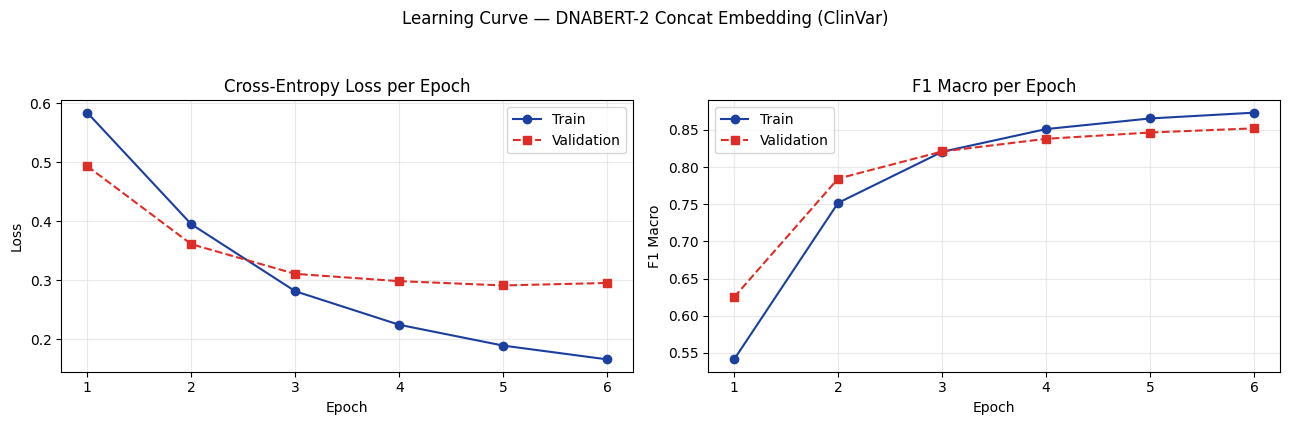

In [13]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train", color="#1e40af")
axes[0].plot(epochs_range, history["val_loss"],   "s--", label="Validation", color="#dc2626")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-Entropy Loss per Epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_f1"], "o-", label="Train", color="#1e40af")
axes[1].plot(epochs_range, history["val_f1"],   "s--", label="Validation", color="#dc2626")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1 Macro")
axes[1].set_title("F1 Macro per Epoch"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Learning Curve — DNABERT-2 Concat Embedding (ClinVar)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "learning_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

## 11. Evaluasi Final

Evaluasi pada test set. Metrik utama: Accuracy, F1 Macro, AUC-ROC.

In [14]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluasi final"):
        ref_ids  = batch["ref_input_ids"].to(DEVICE)
        ref_mask = batch["ref_attention_mask"].to(DEVICE)
        alt_ids  = batch["alt_input_ids"].to(DEVICE)
        alt_mask = batch["alt_attention_mask"].to(DEVICE)
        lbls     = batch["label"]

        logits = model(alt_ids, alt_mask, ref_ids, ref_mask)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        preds  = np.argmax(probs, axis=-1)
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())
        all_probs.extend(probs)

all_probs = np.array(all_probs)
acc    = accuracy_score(all_labels, all_preds)
f1_mac = f1_score(all_labels, all_preds, average="macro",    zero_division=0)
f1_wei = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

try:
    auc = roc_auc_score(all_labels, all_probs[:, 1])
except Exception:
    auc = float("nan")

print("=" * 55)
print("Hasil Evaluasi Final (Test Set)")
print("=" * 55)
print(f"Accuracy      : {acc:.4f}")
print(f"F1 Macro      : {f1_mac:.4f}")
print(f"F1 Weighted   : {f1_wei:.4f}")
print(f"AUC-ROC       : {auc:.4f}")
print()
print("Referensi AUC DNABERT-2 zero-shot (Feng et al. 2025): ~0.65-0.68")
print("Fine-tuning seharusnya meningkatkan AUC di atas nilai ini.")
print()
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

metrics = {
    "accuracy": float(acc), "f1_macro": float(f1_mac),
    "f1_weighted": float(f1_wei), "auc_roc": float(auc),
    "num_classes": NUM_CLASSES, "label_names": LABEL_NAMES,
    "reference_zero_shot_auc_dnabert2": "0.65-0.68 (Feng et al. 2025)",
}
with open(os.path.join(MODEL_SAVE_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Metrik disimpan: {MODEL_SAVE_DIR}/metrics.json")

Evaluasi final:   0%|          | 0/63 [00:00<?, ?it/s]

Hasil Evaluasi Final (Test Set)
Accuracy      : 0.8550
F1 Macro      : 0.8521
F1 Weighted   : 0.8545
AUC-ROC       : 0.9245

Referensi AUC DNABERT-2 zero-shot (Feng et al. 2025): ~0.65-0.68
Fine-tuning seharusnya meningkatkan AUC di atas nilai ini.

              precision    recall  f1-score   support

      Benign       0.85      0.89      0.87       544
  Pathogenic       0.86      0.81      0.84       456

    accuracy                           0.86      1000
   macro avg       0.86      0.85      0.85      1000
weighted avg       0.86      0.86      0.85      1000

Metrik disimpan: /kaggle/working/models/metrics.json


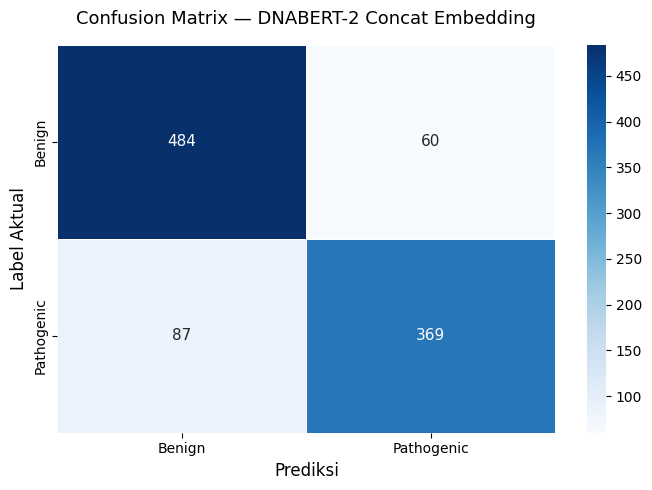

In [ ]:
    cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
    cmap="Blues", ax=ax, linewidths=0.5, linecolor="white",
)
ax.set_xlabel("Prediksi", fontsize=11)
ax.set_ylabel("Label Aktual", fontsize=11)
ax.set_title("Confusion Matrix — DNABERT-2 Concat Embedding", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12. Penyimpanan Model

File tersimpan di `/kaggle/working/models/` — unduh dari tab **Output** Kaggle.

In [16]:
pt_path = os.path.join(MODEL_SAVE_DIR, "dnabert2_finetuned.pt")
torch.save(model.state_dict(), pt_path)
print(f"State dict    : {pt_path}")

hf_dir = os.path.join(MODEL_SAVE_DIR, "dnabert2_encoder_hf")
model.encoder.save_pretrained(hf_dir)
tokenizer.save_pretrained(hf_dir)
print(f"HF encoder    : {hf_dir}")

config_save = {
    "model_name": MODEL_NAME, "num_classes": NUM_CLASSES,
    "label_names": LABEL_NAMES, "hidden_dim": HIDDEN_DIM,
    "dropout": DROPOUT, "max_tok_len": MAX_TOK_LEN,
    "seq_length": SEQ_LENGTH,
    "dataset": "InstaDeepAI/genomics-long-range-benchmark",
    "task": "variant_effect_pathogenic_clinvar",
    "embedding_strategy": "concat[mean_pool(alt) || mean_pool(ref) || (alt-ref)]",
    "input_dim_to_classifier": 768 * 3,
    "class_weights": MANUAL_CLASS_WEIGHTS,
    "reference": "Feng et al., Nature Comms 2025, doi:10.1038/s41467-025-65823-8",
    "train_size": len(train_raw), "test_size": len(test_raw),
    "epochs": EPOCHS, "lr": LR, "batch_size": BATCH_SIZE,
    "freeze_epochs": FREEZE_EPOCHS, "seed": SEED,
    "metrics": metrics,
}
with open(os.path.join(MODEL_SAVE_DIR, "training_config.json"), "w") as f:
    json.dump(config_save, f, indent=2, default=str)
print(f"Config        : {MODEL_SAVE_DIR}/training_config.json")

print()
print("Semua file tersimpan:")
for fname in sorted(os.listdir(MODEL_SAVE_DIR)):
    fpath = os.path.join(MODEL_SAVE_DIR, fname)
    size  = os.path.getsize(fpath) if os.path.isfile(fpath) else 0
    print(f"  {fname:<52} {size/1e6:7.1f} MB" if size > 0 else f"  {fname}/")

State dict    : /kaggle/working/models/dnabert2_finetuned.pt
HF encoder    : /kaggle/working/models/dnabert2_encoder_hf
Config        : /kaggle/working/models/training_config.json

Semua file tersimpan:
  class_distribution.png                                   0.1 MB
  confusion_matrix.png                                     0.0 MB
  dnabert2_encoder_hf/
  dnabert2_finetuned.pt                                  469.9 MB
  learning_curve.png                                       0.1 MB
  metrics.json                                             0.0 MB
  training_config.json                                     0.0 MB


## 13. Demo Inferensi

Inferensi menggunakan pasangan ref + alt dari test set.

In [17]:
def predict_variant(ref_seq: str, alt_seq: str) -> dict:
    """Prediksi patogenisitas dari pasangan (ref, alt) sekuens DNA."""
    model.eval()

    def tok(seq):
        enc = tokenizer(
            seq.upper(), max_length=MAX_TOK_LEN,
            padding="max_length", truncation=True, return_tensors="pt",
        )
        return enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE)

    ref_ids, ref_mask = tok(ref_seq)
    alt_ids, alt_mask = tok(alt_seq)

    with torch.no_grad():
        logits = model(alt_ids, alt_mask, ref_ids, ref_mask)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    idx = int(np.argmax(probs))
    return {
        "label":         LABEL_NAMES[idx],
        "confidence":    float(probs[idx]),
        "probabilities": {k: float(v) for k, v in zip(LABEL_NAMES, probs)},
    }


example  = dict(test_raw[0])
ref_seq  = example["ref_forward_sequence"]
alt_seq  = example["alt_forward_sequence"]
true_lbl = LABEL_NAMES[int(example["label"])]

result = predict_variant(ref_seq, alt_seq)

print(f"ref (50 bp pertama) : {ref_seq[:50]}...")
print(f"alt (50 bp pertama) : {alt_seq[:50]}...")
print(f"Label aktual        : {true_lbl}")
print()
print("Hasil prediksi:")
print(f"  Label      : {result['label']}")
print(f"  Confidence : {result['confidence']*100:.1f}%")
print()
for cls, prob in result["probabilities"].items():
    bar = "#" * int(prob * 30)
    status = "<-- prediksi" if cls == result["label"] else ""
    print(f"    {cls:<12} {prob:.3f}  {bar}  {status}")

ref (50 bp pertama) : TGGAAATTTACAAATCTGTGTTCCTGCTTTTTTCCCTTTTAAGGCCTCGA...
alt (50 bp pertama) : TGGAAATTTACAAATCTGTGTTCCTGCTTTTTTCCCTTTTAAGGCCTCGA...
Label aktual        : Pathogenic

Hasil prediksi:
  Label      : Benign
  Confidence : 63.5%

    Benign       0.635  ###################  <-- prediksi
    Pathogenic   0.365  ##########  


## Selesai

**File output di Kaggle** (`/kaggle/working/models/`):
- `dnabert2_finetuned.pt` — bobot model (state dict)
- `dnabert2_encoder_hf/` — encoder DNABERT-2 format HuggingFace
- `metrics.json` — hasil evaluasi (accuracy, F1, AUC-ROC)
- `training_config.json` — konfigurasi lengkap termasuk metodologi
- `learning_curve.png` — grafik loss & F1
- `confusion_matrix.png` — confusion matrix
- `class_distribution.png` — distribusi kelas

**Setelah download:**
1. Taruh `dnabert2_finetuned.pt` di folder `models/`
2. Set `MOCK_ML=false` di `.env`
3. Jalankan `python scripts/evaluate.py`

**Referensi metodologi:**
Feng et al. (2025). Benchmarking DNA foundation models for genomic and genetic tasks.
*Nature Communications*, 16, 10780. https://doi.org/10.1038/s41467-025-65823-8